In [18]:
# Configuração geral
CONFIG = {
    "img_size": 224,
    "batch_size": 32,
    "epochs": 25,
    "lr": 1e-4,
    "num_workers": 2,
    "dataset_path": "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017",
    "num_classes": 2,
    "model_name": "comparison_cnn_vs_densenet"
}


In [19]:
# imports
import os, json, torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
# relatorio, matriz de confusao e visualização
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)


Device: cuda


In [20]:
# Dataset (Base para CNN e DenseNet)
# Usada para cnn construida, densenet, treino e teste (nao muda entre os modelos)
class CocoBinaryDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        with open(annotation_file) as f:
            data = json.load(f)
        self.images = data['images']
        self.annotations = data['annotations']
        self.labels = {img['id']: 0 for img in self.images}
        for ann in self.annotations:
            if ann['category_id'] == 1:
                self.labels[ann['image_id']] = 1

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        path = os.path.join(self.image_dir, img_info['file_name'])
        # contorno para crashes no kaggle relativos a imagem
        try:
            image = Image.open(path).convert('RGB')
        except:
            return self.__getitem__((idx + 1) % len(self.images))
        
        label = int(self.labels[img_info['id']])
        if self.transform:
            image = self.transform(image)
        return image, label

In [21]:
# Pré-processamento
# Todos os modelos usam. Serve para cnn construída, densenet , treino teste
transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    # Normalizando com valores do imagenet:
    # Essa melhoria de normalizaão deixa o aprendizado mais rápido e
    # aprimora a generalização levando em conta que a densenet 
    # perde desempenho
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    #.
])

In [22]:
# Dataset + DataLoaders (Base do Experimento)
# Usada or cnn construída, densenet. Obs.: Não duplicar
# =========================
# dataset de treino
# =========================
train_dataset = CocoBinaryDataset(
    image_dir=f"{CONFIG['dataset_path']}/train2017",
    annotation_file=f"{CONFIG['dataset_path']}/annotations/instances_train2017.json",
    transform=transform
)

# Reduzindo o dataset de treino
import random
from torch.utils.data import Subset, DataLoader
# melhoria: garantindo que serão pegas as mesmas imagens
# garantindo resultados comparáveis entre cnn e a densenet
random.seed(42)
#.
train_indices = random.sample(range(len(train_dataset)), 5000)
train_dataset = Subset(train_dataset, train_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers']
)

# =========================
# dataset de teste
# =========================
test_dataset = CocoBinaryDataset(
    image_dir=f"{CONFIG['dataset_path']}/val2017",
    annotation_file=f"{CONFIG['dataset_path']}/annotations/instances_val2017.json",
    transform=transform
)

# Reduzindo também (pra ficar rápido)
test_indices = random.sample(range(len(test_dataset)), 1000)
test_dataset = Subset(test_dataset, test_indices)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    # nao embaralhar no teste
    shuffle=False,  
    num_workers=CONFIG['num_workers']
)

# sanity check
view_sanity_check = False
if view_sanity_check:
    print(f"Treino: {len(train_dataset)} imagens")
    print(f"Teste: {len(test_dataset)} imagens")

In [23]:
# Criação da CNN da equipe 2
import torch.nn.functional as F

class cnn_equipe2(nn.Module):
    def __init__(self):
        super(cnn_equipe2, self).__init__()

        # Conceito de Blocos: Blocos convolucionais
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # Adaptive (evita problema com tamanho da imagem)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # Camadas densas
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, CONFIG['num_classes'])

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.adaptive_pool(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model_cnn = cnn_equipe2().to(device)

In [24]:
# Transfer Learning com Densenet
model_dense = models.densenet121(pretrained=True)

# congelar as features
for param in model_dense.features.parameters():
    param.requires_grad = False

# adaptar classificador (camada densa)
model_dense.classifier = nn.Linear(
    model_dense.classifier.in_features,
    CONFIG['num_classes']
)

model_dense = model_dense.to(device)

In [25]:
# Setup de treino
# Meta: suportar model_cnn (cnn da equipe 2) e model_dense

# Loss mesma para os dois modelos
criterion = nn.CrossEntropyLoss()

# Otimização

# CNN da equipe 2
# Melhoria: aumentado o learning rate da CNNEquipe2
# optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=CONFIG['lr'])
# Testado com 15 e 25 epocas
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=1e-3)
# TODO: Testar respectivamente de 25 a 30 epocas
# optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=5e-4)
# optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=2e-3)
# .
# DenseNet (só treina o classificador)
optimizer_dense = optim.Adam(model_dense.classifier.parameters(), lr=CONFIG['lr'])

In [26]:
# Treinamento
# Função de treino reutilizável para model_cnn e model_dense
# Recap: model_cnn é a cnn da equipe 2 e model_dense é a densenet
def train_model(model, optimizer, name="Model"):
    print(f"\nTreinando: {name}")

    for epoch in range(CONFIG['epochs']):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"{name} | Epoch {epoch+1}/{CONFIG['epochs']} - Loss: {total_loss:.4f}")

In [27]:
# Treinar os modelos
train_model(model_cnn, optimizer_cnn, name="CNNEquipe2")
train_model(model_dense, optimizer_dense, name="DenseNet")


Treinando: CNNEquipe2
CNNEquipe2 | Epoch 1/25 - Loss: 106.8261
CNNEquipe2 | Epoch 2/25 - Loss: 104.2736
CNNEquipe2 | Epoch 3/25 - Loss: 103.5669
CNNEquipe2 | Epoch 4/25 - Loss: 102.5658
CNNEquipe2 | Epoch 5/25 - Loss: 101.1083
CNNEquipe2 | Epoch 6/25 - Loss: 99.8386
CNNEquipe2 | Epoch 7/25 - Loss: 97.9880
CNNEquipe2 | Epoch 8/25 - Loss: 97.4785
CNNEquipe2 | Epoch 9/25 - Loss: 94.8023
CNNEquipe2 | Epoch 10/25 - Loss: 93.8708
CNNEquipe2 | Epoch 11/25 - Loss: 90.5929
CNNEquipe2 | Epoch 12/25 - Loss: 89.1874
CNNEquipe2 | Epoch 13/25 - Loss: 86.2225
CNNEquipe2 | Epoch 14/25 - Loss: 82.0096
CNNEquipe2 | Epoch 15/25 - Loss: 78.9366
CNNEquipe2 | Epoch 16/25 - Loss: 74.3851
CNNEquipe2 | Epoch 17/25 - Loss: 70.2563
CNNEquipe2 | Epoch 18/25 - Loss: 62.9543
CNNEquipe2 | Epoch 19/25 - Loss: 57.7690
CNNEquipe2 | Epoch 20/25 - Loss: 50.1711
CNNEquipe2 | Epoch 21/25 - Loss: 46.0259
CNNEquipe2 | Epoch 22/25 - Loss: 38.2781
CNNEquipe2 | Epoch 23/25 - Loss: 30.9952
CNNEquipe2 | Epoch 24/25 - Loss: 25.95

In [28]:
# Avaliação
def evaluate_model(model, name="Model"):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"\n{name} - Acurácia: {accuracy:.2f}%")
    print(classification_report(all_labels, all_preds))

    return accuracy, all_labels, all_preds

In [29]:
# Avaliação dos modelos
acc_cnn, labels_cnn, preds_cnn = evaluate_model(model_cnn, "CNNEquipe2")
acc_dense, labels_dense, preds_dense = evaluate_model(model_dense, "DenseNet")


CNNEquipe2 - Acurácia: 66.10%
              precision    recall  f1-score   support

           0       0.63      0.64      0.64       464
           1       0.68      0.68      0.68       536

    accuracy                           0.66      1000
   macro avg       0.66      0.66      0.66      1000
weighted avg       0.66      0.66      0.66      1000


DenseNet - Acurácia: 86.20%
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       464
           1       0.91      0.82      0.86       536

    accuracy                           0.86      1000
   macro avg       0.86      0.87      0.86      1000
weighted avg       0.87      0.86      0.86      1000



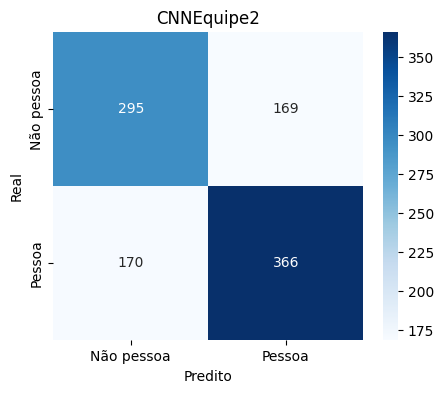

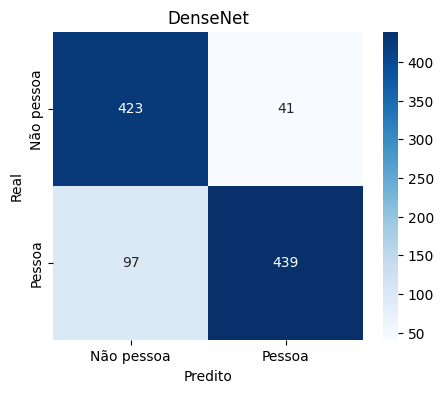

In [30]:
# matriz de confusao
def plot_confusion_matrix(labels, preds, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Não pessoa", "Pessoa"],
                yticklabels=["Não pessoa", "Pessoa"])
    
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()


plot_confusion_matrix(labels_cnn, preds_cnn, "CNNEquipe2")
plot_confusion_matrix(labels_dense, preds_dense, "DenseNet")

In [31]:
# setup para visualizar as imagens por página
# de acordo com os modelos
import matplotlib.pyplot as plt
# melhoria:
# para nao ter que visualizar com as cores ruins (normalizadas)
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.cpu().permute(1, 2, 0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img
# .
classes = ["Não pessoa", "Pessoa"]

def show_batch(images, labels, preds):
    plt.figure(figsize=(12, 6))

    for i in range(len(images)):
        # melhoria
        #img = images[i].cpu().permute(1, 2, 0).numpy()
        img = img = denormalize(images[i])
        # .
        real = labels[i]
        prev = preds[i]

        if real == prev:
            color = "white"
            backgroundcolor = "green"
        else:
            color = "white"
            backgroundcolor = "red"

        title = f"Real: {classes[real]}\nPrev: {classes[prev]}"

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(title, fontsize=12, color=color, backgroundcolor=backgroundcolor)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_model(model, name="Modelo"):
    print(f"\n🔍 Visualizando: {name}")
    
    model.eval()

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(test_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            print(f"Página {batch_idx + 1}")
            show_batch(images[:8], labels[:8], preds[:8])

            if batch_idx == 4:
                break

def visualizar(opcao=False):
    if opcao == 'modelo-equipe':
        visualize_model(model_cnn, "CNNEquipe2")
    if opcao == 'modelo-densenet':
        visualize_model(model_dense, "DenseNet")
    if not opcao:
        print("visualizar(opcao=['modelo-equipe' | 'desenet']")


🔍 Visualizando: CNNEquipe2
Página 1


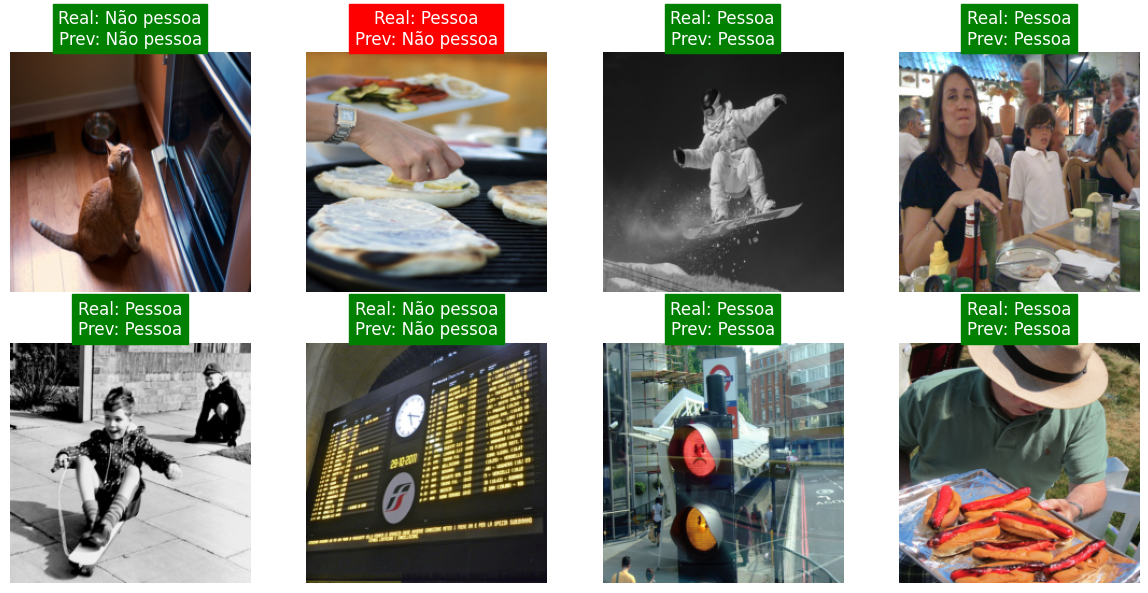

Página 2


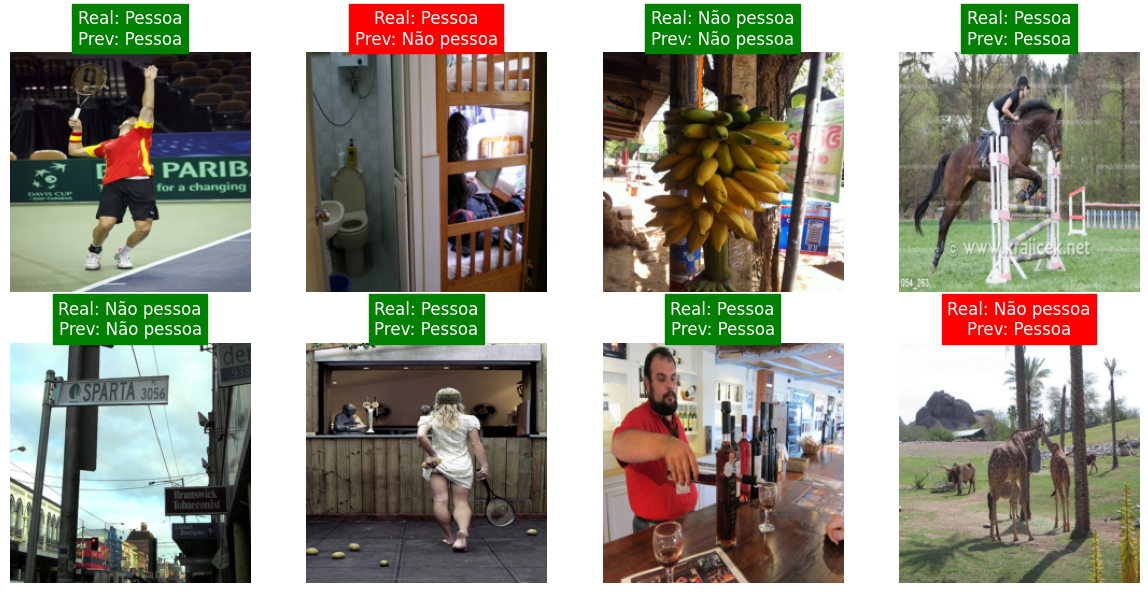

Página 3


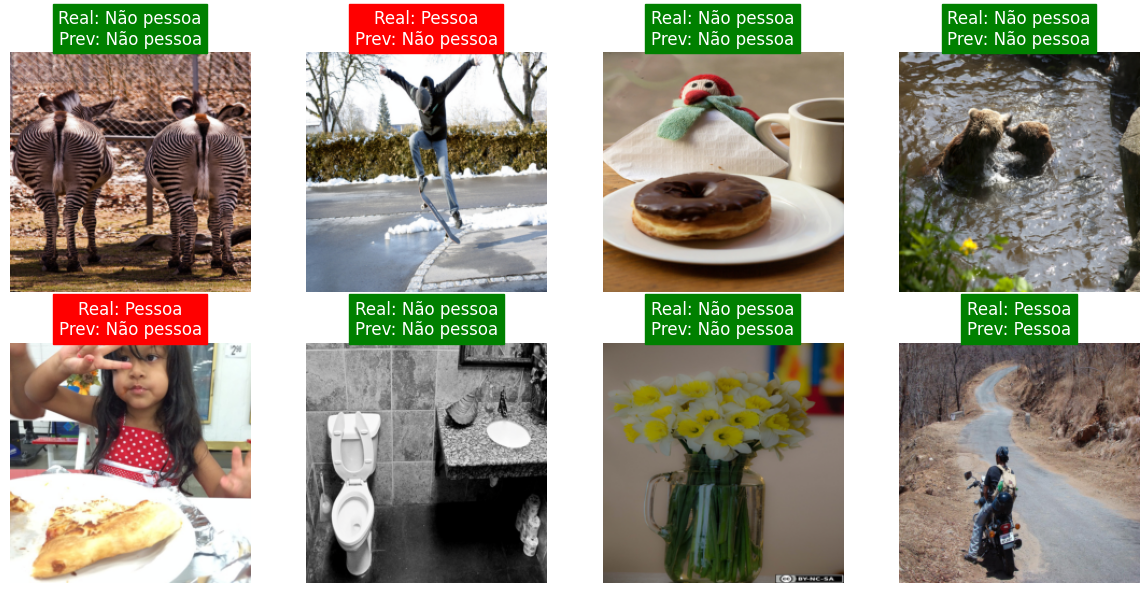

Página 4


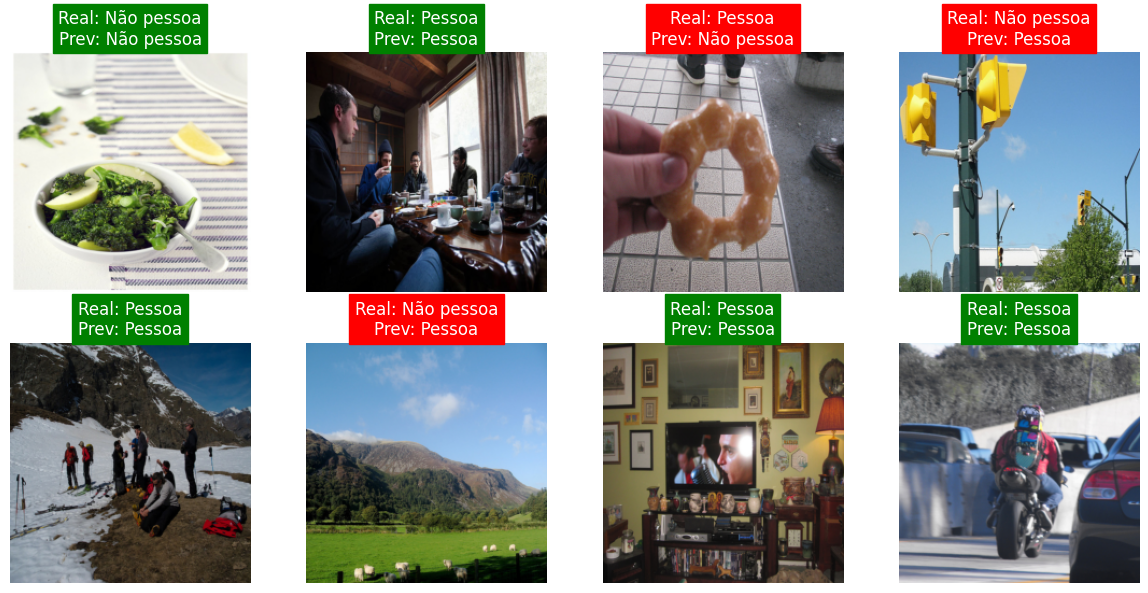

Página 5


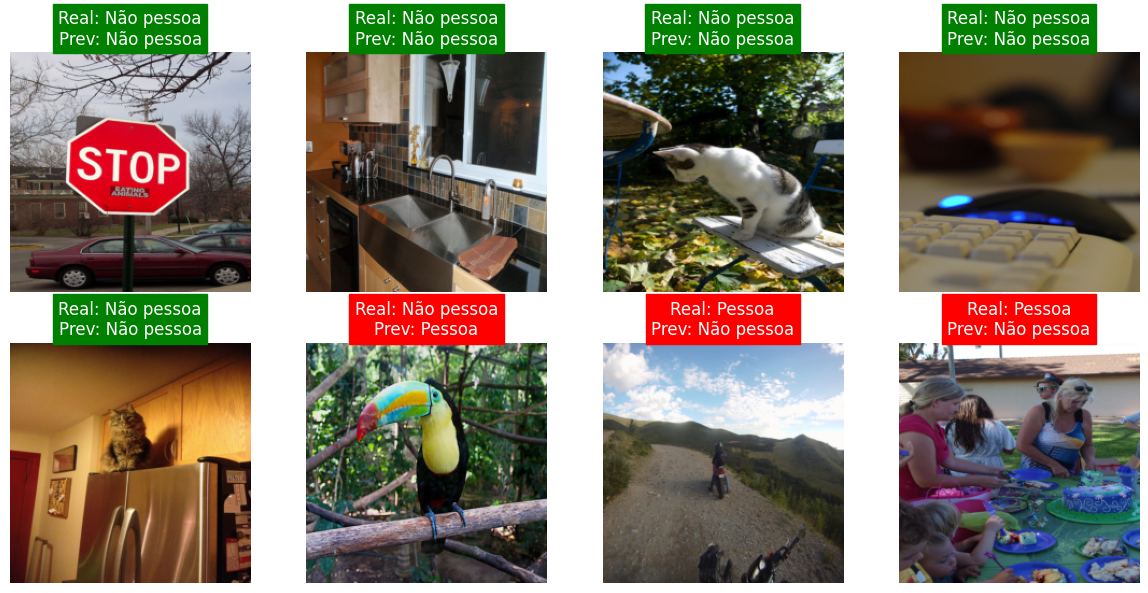

In [32]:
# visualizar as imagens por página
# de acordo com os modelos
visualizar('modelo-equipe')